# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [1]:
# import thu vien
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


## Tải dữ liệu

In [2]:
# lay thu muc goc cua project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# duong dan du lieu
BASE_DIR = str(PROJECT_ROOT / "data")
RAW_DIR = os.path.join(BASE_DIR, "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed")

TRAIN_PATH = os.path.join(RAW_DIR, "train_raw.csv")
VAL_PATH = os.path.join(RAW_DIR, "val_raw.csv")
TEST_PATH = os.path.join(RAW_DIR, "test_raw.csv")

TEXT_COL = "free_text"
LABEL_COL = "label_id"

LABEL_MAP = {
    0: "CLEAN",
    1: "OFFENSIVE",
    2: "HATE"
}


In [3]:
# doc du lieu
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

assert TEXT_COL in train_df.columns and LABEL_COL in train_df.columns
assert TEXT_COL in val_df.columns and LABEL_COL in val_df.columns
assert TEXT_COL in test_df.columns and LABEL_COL in test_df.columns

train_df.shape, val_df.shape, test_df.shape

((24048, 2), (2672, 2), (6680, 2))

## Kiểm tra dữ liệu

In [4]:
# xem du lieu
train_df.head()

,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


In [5]:
# kiem tra null va phan bo nhan
print(train_df[[TEXT_COL, LABEL_COL]].isnull().sum())
print()
print(train_df[LABEL_COL].value_counts().sort_index())

free_text    2
label_id     0
dtype: int64

label_id
0    19886
1     1606
2     2556
Name: count, dtype: int64


## Khám phá dữ liệu

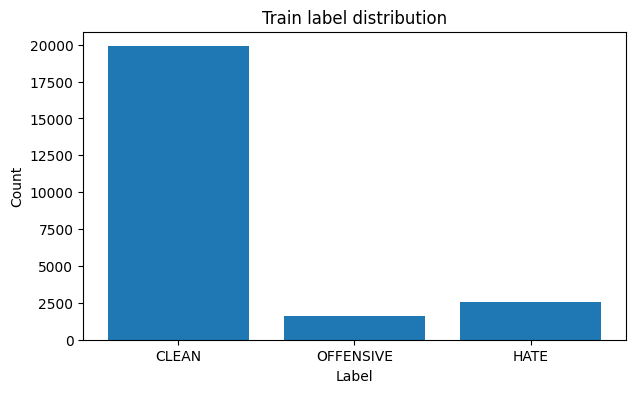

In [6]:
# ve phan bo nhan
label_count = train_df[LABEL_COL].value_counts().sort_index()
label_name = [LABEL_MAP.get(i, str(i)) for i in label_count.index]

plt.figure(figsize=(7, 4))
plt.bar(label_name, label_count.values)
plt.title("Train label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [7]:
# thong ke do dai
train_text = train_df[TEXT_COL].fillna("").astype(str)

char_len = train_text.str.len()
word_len = train_text.str.split().str.len()

char_p99 = char_len.quantile(0.99)
word_p99 = word_len.quantile(0.99)

length_stats = pd.DataFrame({
    "stat": ["mean", "median", "p95", "p99", "max"],
    "char_len": [
        round(char_len.mean(), 2),
        round(char_len.median(), 2),
        round(char_len.quantile(0.95), 2),
        round(char_p99, 2),
        int(char_len.max())
    ],
    "word_len": [
        round(word_len.mean(), 2),
        round(word_len.median(), 2),
        round(word_len.quantile(0.95), 2),
        round(word_p99, 2),
        int(word_len.max())
    ]
})

length_stats

,stat,char_len,word_len
0,mean,49.28,11.51
1,median,33.00,8.00
2,p95,136.00,32.00
3,p99,252.53,60.00
4,max,20816.00,1701.00


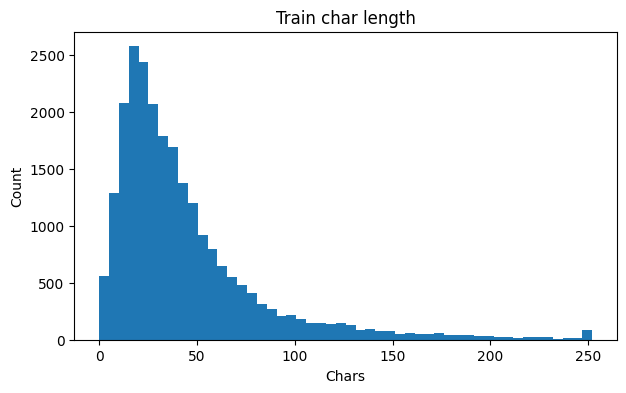

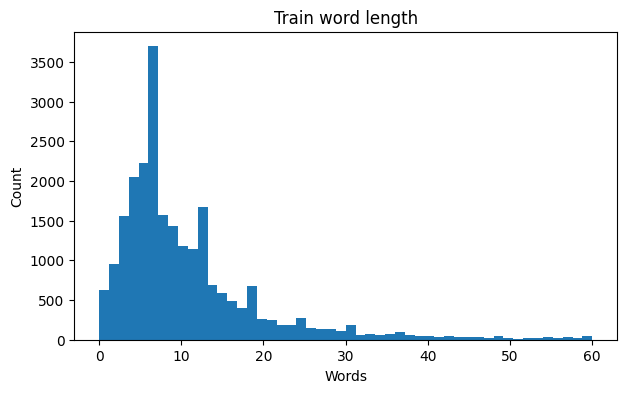

In [8]:
# ve do dai binh luan
plt.figure(figsize=(7, 4))
plt.hist(char_len[char_len <= char_p99], bins=50)
plt.title("Train char length")
plt.xlabel("Chars")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(word_len[word_len <= word_p99], bins=50)
plt.title("Train word length")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

## Tiền xử lý

In [9]:
# ham xu ly text
url_pattern = re.compile(r"https?://\S+|www\.\S+")

def clean_text(text):
    if pd.isna(text):
        return np.nan
    text = str(text)
    text = text.replace("\n", " ").replace("\t", " ")
    text = url_pattern.sub("[URL]", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def to_label_id(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip().upper()
        if value in ["CLEAN", "OFFENSIVE", "HATE"]:
            return {"CLEAN": 0, "OFFENSIVE": 1, "HATE": 2}[value]
    try:
        value = int(value)
        if value in LABEL_MAP:
            return value
    except:
        pass
    return np.nan

def preprocess(df):
    data = df[[TEXT_COL, LABEL_COL]].copy()
    data["text_original"] = data[TEXT_COL]
    data["text_clean"] = data[TEXT_COL].apply(clean_text)
    data = data.dropna(subset=["text_clean", LABEL_COL]).copy()
    data = data[data["text_clean"].str.strip() != ""].copy()
    data["label_id"] = data[LABEL_COL].apply(to_label_id)
    data = data.dropna(subset=["label_id"]).copy()
    data["label_id"] = data["label_id"].astype(int)
    data["label_name"] = data["label_id"].map(LABEL_MAP)
    data["label_binary"] = data["label_id"].apply(lambda x: 0 if x == 0 else 1)
    return data[["text_original", "text_clean", "label_id", "label_name", "label_binary"]]

train_processed = preprocess(train_df)
val_processed = preprocess(val_df)
test_processed = preprocess(test_df)

train_processed.shape, val_processed.shape, test_processed.shape

((24046, 5), (2672, 5), (6680, 5))

In [10]:
# xem du lieu sau xu ly
train_processed.head()

,text_original,text_clean,label_id,label_name,label_binary
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0,CLEAN,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2,HATE,1
2,Đậu Văn Cường giờ giống thằng sida hơn à,Đậu Văn Cường giờ giống thằng sida hơn à,0,CLEAN,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2,HATE,1
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0,CLEAN,0


## Lưu dữ liệu

In [11]:
# luu file processed
os.makedirs(PROCESSED_DIR, exist_ok=True)

train_processed.to_csv(os.path.join(PROCESSED_DIR, "train_processed.csv"), index=False)
val_processed.to_csv(os.path.join(PROCESSED_DIR, "val_processed.csv"), index=False)
test_processed.to_csv(os.path.join(PROCESSED_DIR, "test_processed.csv"), index=False)